# Bike Rental Demand Forecasting - Exploratory Data Analysis (EDA)

**Objective:** Analyze bike rental data to understand usage patterns based on time, weather, and seasonal factors — ultimately to build a model that accurately predicts bike rental demand.

**Dataset:** `Dataset.csv` — 17379 records with 17 features capturing temporal, environmental, and user-based information affecting bike rentals.

---



## Step 1: Load & Explore Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [6]:
df = pd.read_csv('Dataset/Dataset.csv')
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset Shape: 17379 rows x 17 columns


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17379 non-null  str  
 3   yr          17379 non-null  str  
 4   mnth        17379 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17379 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17379 non-null  str  
 9   weathersit  17379 non-null  str  
 10  temp        17379 non-null  str  
 11  atemp       17379 non-null  str  
 12  hum         17379 non-null  str  
 13  windspeed   17379 non-null  str  
 14  casual      17379 non-null  str  
 15  registered  17379 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 2.3 MB


In [8]:
# Rename columns to meaningful names

df.rename(columns={
    'instant': 'record_id',
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'hum': 'humidity',
    'cnt': 'total_rentals'
}, inplace=True)

print("Renamed Columns:\n", df.columns)

Renamed Columns:
 Index(['record_id', 'date', 'season', 'year', 'month', 'hour', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'humidity',
       'windspeed', 'casual', 'registered', 'total_rentals'],
      dtype='str')


In [9]:
# Column names grouped by category for reference

time_cols = ['date', 'year', 'month', 'hour', 'weekday']
seasonal_cols = ['season']
weather_cols = ['weathersit', 'temp', 'atemp', 'humidity', 'windspeed']
day_type_cols = ['holiday', 'workingday']
user_cols = ['casual', 'registered']
target_col = ['total_rentals']

print(f'Time columns        ({len(time_cols)}): {time_cols}')
print(f'Season columns      ({len(seasonal_cols)}): {seasonal_cols}')
print(f'Weather columns     ({len(weather_cols)}): {weather_cols}')
print(f'Day Type columns    ({len(day_type_cols)}): {day_type_cols}')
print(f'User columns        ({len(user_cols)}): {user_cols}')
print(f'Target column       ({len(target_col)}): {target_col}')
print(f'Other columns: record_id')

Time columns        (5): ['date', 'year', 'month', 'hour', 'weekday']
Season columns      (1): ['season']
Weather columns     (5): ['weathersit', 'temp', 'atemp', 'humidity', 'windspeed']
Day Type columns    (2): ['holiday', 'workingday']
User columns        (2): ['casual', 'registered']
Target column       (1): ['total_rentals']
Other columns: record_id


## Step 2: Data Quality Checks

In [10]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

print(f'Unique record IDs: {df["record_id"].nunique()} out of {len(df)} rows')

Number of duplicate rows: 0
Unique record IDs: 17379 out of 17379 rows


In [11]:
# Check for Missing Values in dataset
question_marks = (df == '?').sum()
print("Count of Missing Values in each column:\n", question_marks)

Count of Missing Values in each column:
 record_id         0
date              0
season            6
year              1
month             1
hour              0
holiday           1
weekday           0
workingday        5
weathersit        4
temp             11
atemp             6
humidity          6
windspeed         5
casual            1
registered        1
total_rentals     0
dtype: int64


## Step 3: Feature Engineering

Creating only high-impact features to improve model performance without unnecessary complexity.

| Feature        | Calculation            | Purpose                          |
| -------------- | ---------------------- | -------------------------------- |
| `Is_Weekend`   | 1 if weekday in [0,6]  | Capture weekend demand variation |
| `Is_Peak_Hour` | 1 if hr in [7-9,17-19] | Capture rush hour demand         |
| `Month`        | extract from dteday    | Seasonal trend                   |


In [12]:
# Convert date
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Weekend flag
df['Is_Weekend'] = df['weekday'].isin([0, 6]).astype(int)

# Peak hour flag
df['Is_Peak_Hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Extract month
df['Month'] = df['date'].dt.month

print('New features created:')
print(df[['Is_Weekend', 'Is_Peak_Hour', 'Month']].describe())

New features created:
         Is_Weekend  Is_Peak_Hour         Month
count  17379.000000  17379.000000  17379.000000
mean       0.288509      0.251280      6.537775
std        0.453082      0.433762      3.438776
min        0.000000      0.000000      1.000000
25%        0.000000      0.000000      4.000000
50%        0.000000      0.000000      7.000000
75%        1.000000      1.000000     10.000000
max        1.000000      1.000000     12.000000


## Step 4: Data Cleaning

Covers descriptive statistics, outlier detection & removal, and categorical variable grouping.

### 4a. Descriptive Statistics

In [13]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
record_id,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
date,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
hour,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
total_rentals,17379.0,189.463088,1.0,40.0,142.0,281.0,977.0,181.387599
Is_Weekend,17379.0,0.288509,0.0,0.0,0.0,1.0,1.0,0.453082
Is_Peak_Hour,17379.0,0.25128,0.0,0.0,0.0,1.0,1.0,0.433762
Month,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776


In [14]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert to numeric safely
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values (numeric → median)
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → fill with mode
cat_cols = ['season', 'year', 'month', 'holiday', 'workingday', 'weathersit']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Final check
print("Remaining Null Values:\n", df.isnull().sum())

Remaining Null Values:
 record_id         0
date              0
season            6
year              1
month             1
hour              0
holiday           1
weekday           0
workingday        5
weathersit        4
temp             11
atemp             6
humidity          6
windspeed         5
casual            1
registered        1
total_rentals     0
Is_Weekend        0
Is_Peak_Hour      0
Month             0
dtype: int64


In [15]:
cat_cols = ['season', 'holiday', 'workingday', 'weathersit']

for col in cat_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percentage': pcts}))


--- season ---
          Count  Percentage
season                     
fall       4496        25.9
summer     4409        25.4
springer   4236        24.4
winter     4232        24.4

--- holiday ---
         Count  Percentage
holiday                   
No       16878        97.1
Yes        500         2.9

--- workingday ---
             Count  Percentage
workingday                    
Working Day  11862        68.3
No work       5512        31.7

--- weathersit ---
            Count  Percentage
weathersit                   
Clear       11412        65.7
Mist         4541        26.1
Light Snow   1419         8.2
Heavy Rain      3         0.0


### 4b. Outlier Detection & Removal
We target key numerical columns affecting demand: temp, atemp, hum, windspeed, and cnt (target variable). These may contain extreme values that can impact model performance.

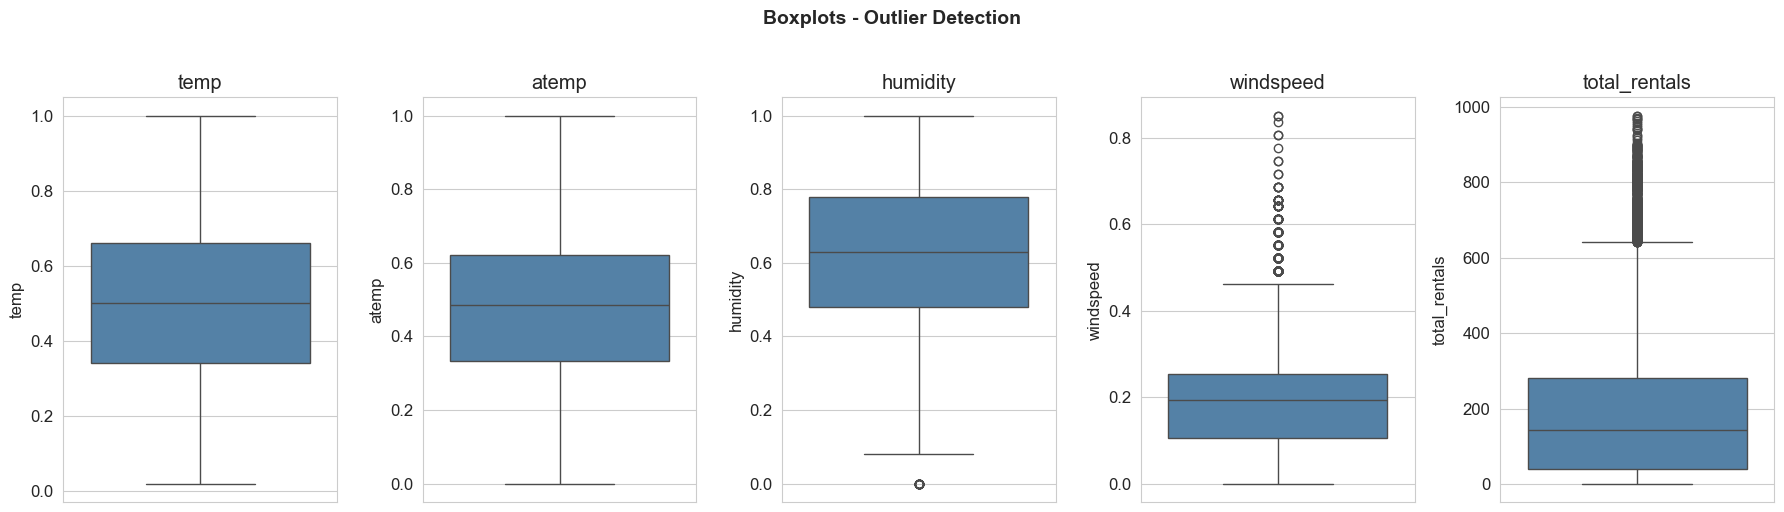

In [16]:
outlier_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_rentals']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Remove outliers using IQR

outlier_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_rentals']

print(f'Rows before removing outliers: {len(df)}')

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f'Rows after removing outliers:  {len(df)}')

Rows before removing outliers: 17379
Rows after removing outliers:  16512


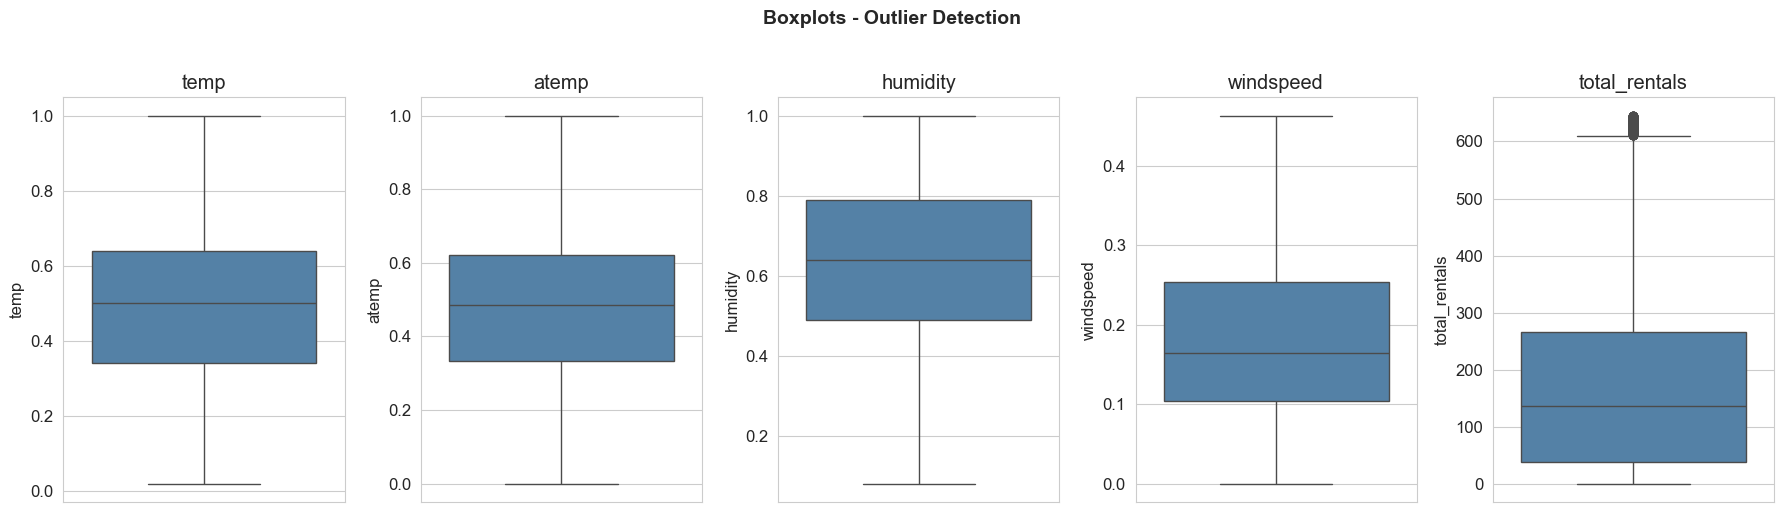

In [18]:
outlier_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_rentals']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()